In [1]:
import torch
import nn4n

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N, C = 512, 100
model_cfg = {
            "input_dim":    C,
            "hidden_dim":   N,
            'output_dim':   C,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: cuda


In [16]:
import numpy as np
load_data_type = '2TS_1_data'

num_neuron = 512
data = np.load(f'../time_exp/{load_data_type}.npy', allow_pickle=True).item()
exp_vectors = data['test_labels']
print(exp_vectors.shape)

torch.Size([7, 200, 100])


(7, 200, 512)


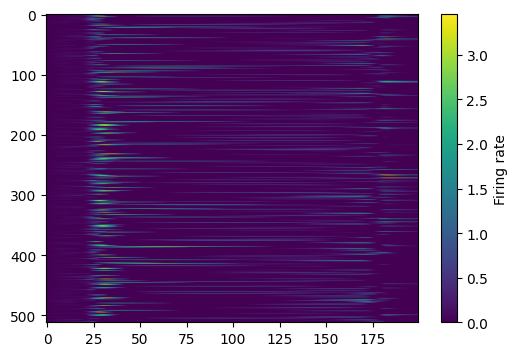

In [25]:
# Load model weights 
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    _, hidden_states_from_RNN = rnn(exp_vectors.to(device))
ref_fr = hidden_states_from_RNN[0].cpu().numpy()
print(ref_fr.shape)
avg_fr = np.mean(ref_fr, axis=0)
# Image show the reference firing rates
from matplotlib import pyplot as plt
plt.figure(figsize=(6,4))
plt.imshow(avg_fr.T, aspect='auto', cmap='viridis') 
plt.colorbar(label='Firing rate')

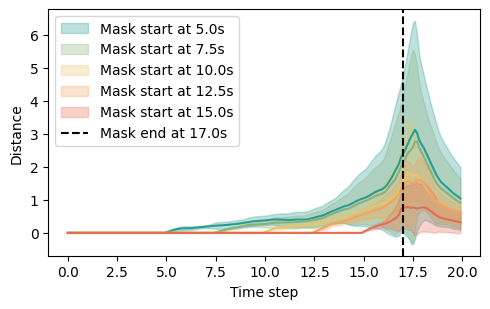

In [43]:
# Partially mask the input

mask_indices = [50, 75, 100, 125, 150,]
colours = ['#299D8F', '#8AB07C',  '#E7C66B', '#F3A361', '#E66D50',]

# colours = [ '#274753', '#297270', '#299D8F',"#4E975E", '#8AB07C',# '#D3D7AF',
#            '#E7C66B', '#F3A361', '#E66D50', "#A3432B"]
# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for idx, mask_idx in enumerate(mask_indices):
    
    test_input = exp_vectors.clone()
    test_input[:, mask_idx:170, :] = 0
    
    # fr = RNNnet.run(exp_vectors)   # -> shape (B,T,N)
    rnn.eval()
    with torch.no_grad():
        _, hidden_states_from_RNN = rnn(test_input.to(device))
    fr = hidden_states_from_RNN[0].cpu().numpy()
    
    # Compute the higher dimensional distance
    dist = np.linalg.norm(fr - ref_fr, axis=-1)  # (B,T)
    
    # Get the mean and std over batch
    mean_dist = np.mean(dist, axis=0)  # (T,)
    std_dist = np.std(dist, axis=0)    # (T,)
    
    # Plot the distance with error bars
    t = np.arange(mean_dist.shape[0])/10  # time in seconds
    ax.plot(t, mean_dist, color=colours[idx])
    ax.fill_between(t, 
                    mean_dist - std_dist,
                    mean_dist + std_dist,
                    color=colours[idx], alpha=0.3,
                    label=f'Mask start at {mask_idx/10:.1f}s')
    # # Plot the vertical dashed line at the mask point
    # ax.axvline(x=mask_idx/10, color=f'C{idx}', linestyle='--', label=f'Mask start at {mask_idx/10:.1f}s')
ax.set_ylabel('Distance')
ax.axvline(x=17, color='black', linestyle='--', label='Mask end at 17.0s')
plt.tight_layout()
plt.legend(loc='best')
plt.xlabel('Time step')
plt.savefig('high_dim_dist.png', transparent=True, dpi=500)